Task-1: Problem Statement  

Task-2: Data Exploration and Validation

Task-3: Data Cleaning

Task-4: Model Building Simple Models(Logistic Regregression and
Decision trees)

Task-5: Model Validation metrics calculation

Task-6: Handling Class imbalance(Rebuild Simple ML models)

Task-7: Feature Engineering

Task-8: Ensemble Methods - XGB and RF

Task-9: Model presentation

Task-10: Interview questions on the project




# Project Objective
## Background
## Goal, Number of Resources, Business Impact, Time Taken




# Data Exploration and Validation


# Download from Github

Create a logionid on github
Upload your file on to github, then use the link here


https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset

In [ ]:
#Import the data set from the location https://raw.githubusercontent.com/datavedi1/my_datasets/main/credit_risk_data/UCI_Credit_Card.csv
import pandas as pd
credit_risk_data=pd.read_csv("https://raw.githubusercontent.com/datavedi1/my_datasets/main/credit_risk_data/UCI_Credit_Card.csv")
credit_risk_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
credit_risk_data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,EDUCATION_New,MARRIAGE_New
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,2,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,2,2
2,3,90000.0,2,2,2,34,0,0,0,0,...,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,2,2
3,4,50000.0,2,2,1,37,0,0,0,0,...,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,2,1
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,2,1


In [ ]:
credit_risk_data.shape

(30000, 27)

In [ ]:
credit_risk_data.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month', 'EDUCATION_New', 'MARRIAGE_New'],
      dtype='object')

Data is shared on
1. internal server - Github
2. Share drive
3. on SQL server


# Data Exploration

##Variables Divison into three categories

In [ ]:
'''['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month']
'''

#Categorical features
cat_vars=['SEX','EDUCATION','MARRIAGE','default.payment.next.month']
#Discrete
discrete_vars=['PAY_0','PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',]
#Continuous
continuous_vars=['LIMIT_BAL','AGE','BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## Explore Cat & discrete Vars by using Fre tables

In [ ]:
# Explore Cat & discrete Vars by using Fre tables
for var_x in cat_vars:
    print(credit_risk_data[var_x].value_counts())


SEX
2    18112
1    11888
Name: count, dtype: int64
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


## Discrete variables exploration


In [ ]:
for disc_var in discrete_vars:
    print(credit_risk_data[disc_var].value_counts())

PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64
PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1
Name: count, dtype: int64
PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3
Name: count, dtype: int64
PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2
Name: count, dtype: int64
PAY_5
 0    16947
-1     5539
-2     4546
 2     2626
 3      178
 4       84
 7       58
 5       17
 6        4
 8        1
Name: count, dtype: int64
PAY_6
 0    16286
-1     5740
-2     4895
 2     2766
 3      184
 4       49
 7       46
 6       19
 5       13
 8        2
Name: count, dtype: int64


#Note
 1. All the categorical variables are looking fine

 2. In discrete vars there are some extreme values in PAY_1,PAY_2....PAY_5 Vars

 3. Unknown values in Education & Marital Status


## Continuous Variables Exploration

In [ ]:
# Continous Variables by using Percentile

credit_risk_data[continuous_vars].describe()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [ ]:
continuous_vars

['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [ ]:
credit_risk_data['LIMIT_BAL'].quantile([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

,LIMIT_BAL
0.0,10000.0
0.1,30000.0
0.2,50000.0
0.3,70000.0
0.4,100000.0
0.5,140000.0
0.6,180000.0
0.7,210000.0
0.8,270000.0
0.9,360000.0


In [ ]:
credit_risk_data['LIMIT_BAL'].quantile([0.9,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99,1])

,LIMIT_BAL
0.90,360000.0
0.91,360000.0
0.92,380000.0
0.93,390000.0
0.94,410000.0
0.95,430000.0
0.96,460000.0
0.97,500000.0
0.98,500000.0
0.99,500000.0


##Note
1. Limit balance has outliers - 1%




In [ ]:
credit_risk_data['AGE'].quantile([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

,AGE
0.0,21.0
0.1,25.0
0.2,27.0
0.3,29.0
0.4,31.0
0.5,34.0
0.6,37.0
0.7,40.0
0.8,43.0
0.9,49.0


In [ ]:
credit_risk_data['AGE'].quantile([0,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99,1])

,AGE
0.00,21.0
0.91,49.0
0.92,50.0
0.93,51.0
0.94,52.0
0.95,53.0
0.96,54.0
0.97,55.0
0.98,57.0
0.99,60.0


# Data Cleaning and Data Preparation

In [ ]:
credit_risk_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

## Var2 Cleaning

EDUCATION VARIABLE CLEANING

In [ ]:
credit_risk_data['EDUCATION_New']=credit_risk_data['EDUCATION']
credit_risk_data['EDUCATION_New'][credit_risk_data['EDUCATION'].isin([0,5,6])] = "Unknown"
credit_risk_data['EDUCATION_New'].value_counts()

/tmp/ipykernel_41297/2157071444.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  credit_risk_data['EDUCATION_New'][credit_risk_data['EDUCATION'].isin([0,5,6])] = "Unknown"
/tmp/ipykernel_41297/2157071444.py:2: SettingWithCopyWarning: 
A v

,count
EDUCATION_New,
2,14030
1,10585
3,4917
Unknown,345
4,123


#CLEANING MARRIAGE VARIABLE

DISCRETE VARS CLEANING

In [ ]:
credit_risk_data['MARRIAGE_New']=credit_risk_data['MARRIAGE']
credit_risk_data['MARRIAGE_New'][credit_risk_data['MARRIAGE']==0] = "Unknown"

/tmp/ipykernel_41297/2084223371.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  credit_risk_data['MARRIAGE_New'][credit_risk_data['MARRIAGE']==0] = "Unknown"
/tmp/ipykernel_41297/2084223371.py:2: SettingWithCopyWarning: 
A value is tryin

##CLEANING LIMIT_BAL

In [ ]:
credit_risk_data['LIMIT_BAL_New']=credit_risk_data['LIMIT_BAL']
credit_risk_data['LIMIT_BAL_New'][credit_risk_data['LIMIT_BAL']>50000] = 50000
credit_risk_data['LIMIT_BAL_New'].describe()

/tmp/ipykernel_790/3904103262.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  credit_risk_data['LIMIT_BAL_New'][credit_risk_data['LIMIT_BAL']>50000] = 50000
/tmp/ipykernel_790/3904103262.py:2: SettingWithCopyWarning: 
A value is trying t

,LIMIT_BAL_New
count,30000.000000
mean,46214.400000
std,9672.439429
min,10000.000000
25%,50000.000000
50%,50000.000000
75%,50000.000000
max,50000.000000


<Axes: ylabel='LIMIT_BAL_New'>

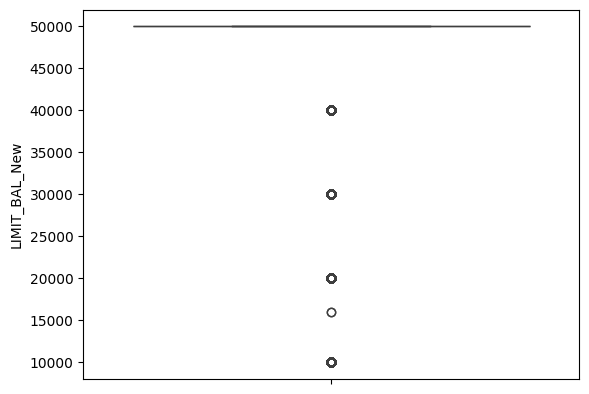

In [ ]:
import seaborn as sns
sns.boxplot(credit_risk_data['LIMIT_BAL_New'])


## CLEANING AGE VARIABLE

In [ ]:
credit_risk_data['AGE_New']=credit_risk_data['AGE']
credit_risk_data['AGE_New'][credit_risk_data['AGE']>60] = 60
credit_risk_data['AGE_New'].describe()

/tmp/ipykernel_790/1062507371.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  credit_risk_data['AGE_New'][credit_risk_data['AGE']>60] = 60
/tmp/ipykernel_790/1062507371.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy

,AGE_New
count,30000.000000
mean,35.444933
std,9.093668
min,21.000000
25%,28.000000
50%,34.000000
75%,41.000000
max,60.000000


<Axes: ylabel='AGE_New'>

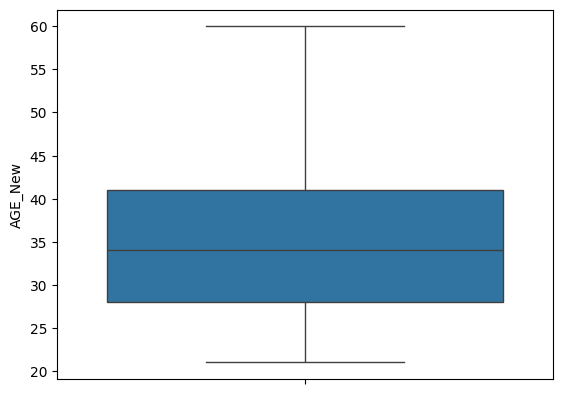

In [ ]:
sns.boxplot(credit_risk_data['AGE_New'])

##CLEANING BILL AMOUNT


In [ ]:
#Any bill amount less than 0 should be replaced with '0' or median
# Any bill amount greater than 3,50,000 should be replaced by 3,50,000


,BILL_AMT1
0,3913.0
1,2682.0
2,29239.0
3,46990.0
4,8617.0
...,...
29995,188948.0
29996,1683.0
29997,3565.0
29998,-1645.0


In [ ]:
credit_risk_data['BILL_AMT1_New']=credit_risk_data['BILL_AMT1']
credit_risk_data['BILL_AMT1_New'][credit_risk_data['BILL_AMT1']<0] = 0
credit_risk_data['BILL_AMT1_New'][credit_risk_data['BILL_AMT1']>350000] =350000
credit_risk_data['BILL_AMT1_New'].describe()

/tmp/ipykernel_790/2054254247.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  credit_risk_data['BILL_AMT1_New'][credit_risk_data['BILL_AMT1']<0] = 0
/tmp/ipykernel_790/2054254247.py:2: SettingWithCopyWarning: 
A value is trying to be set

,BILL_AMT1_New
count,30000.000000
mean,50423.169433
std,69299.159397
min,0.000000
25%,3558.750000
50%,22381.500000
75%,67091.000000
max,350000.000000


<Axes: ylabel='BILL_AMT1_New'>

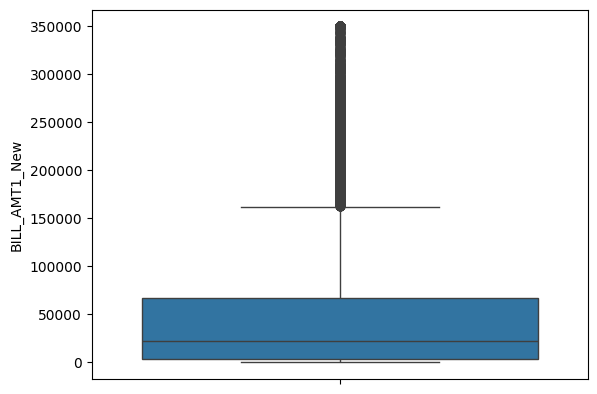

In [ ]:
sns.boxplot(credit_risk_data['BILL_AMT1_New'])

In [ ]:
for i in range(2, 7):
    col_name = f'BILL_AMT{i}'
    new_col_name = f'{col_name}_New'
    credit_risk_data[new_col_name] = credit_risk_data[col_name]
    credit_risk_data.loc[credit_risk_data[col_name] < 0, new_col_name] = 0
    credit_risk_data.loc[credit_risk_data[col_name] > 350000, new_col_name] = 350000
    print(f"Description for {new_col_name}:")
    print(credit_risk_data[new_col_name].describe())
    print("\n")

Description for BILL_AMT2_New:
count     30000.000000
mean      48499.161000
std       67312.918596
min           0.000000
25%        2984.750000
50%       21200.000000
75%       64006.250000
max      350000.000000
Name: BILL_AMT2_New, dtype: float64


Description for BILL_AMT3_New:
count     30000.000000
mean      46398.737700
std       65345.747873
min           0.000000
25%        2666.250000
50%       20088.500000
75%       60164.750000
max      350000.000000
Name: BILL_AMT3_New, dtype: float64


Description for BILL_AMT4_New:
count     30000.000000
mean      42862.793800
std       61673.242298
min           0.000000
25%        2326.750000
50%       19052.000000
75%       54506.000000
max      350000.000000
Name: BILL_AMT4_New, dtype: float64


Description for BILL_AMT5_New:
count     30000.000000
mean      40021.305600
std       58660.512915
min           0.000000
25%        1763.000000
50%       18104.500000
75%       50190.500000
max      350000.000000
Name: BILL_AMT5_New, dtype

<Axes: ylabel='BILL_AMT4_New'>

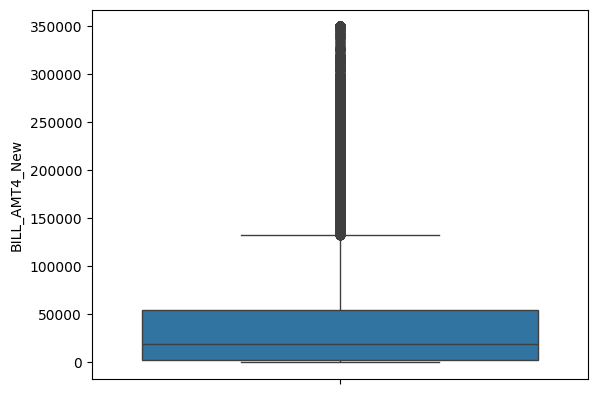

In [ ]:
sns.boxplot(credit_risk_data['BILL_AMT4_New'])

In [ ]:
#DESCRIBE ALL BILL NEW VARIABLES
new_bill_vars=['BILL_AMT1_New','BILL_AMT2_New','BILL_AMT3_New','BILL_AMT4_New','BILL_AMT5_New','BILL_AMT6_New']
credit_risk_data[new_bill_vars].describe()

,BILL_AMT1_New,BILL_AMT2_New,BILL_AMT3_New,BILL_AMT4_New,BILL_AMT5_New,BILL_AMT6_New
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,50423.169433,48499.161000,46398.737700,42862.793800,40021.305600,38662.054133
std,69299.159397,67312.918596,65345.747873,61673.242298,58660.512915,57596.872111
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3558.750000,2984.750000,2666.250000,2326.750000,1763.000000,1256.000000
50%,22381.500000,21200.000000,20088.500000,19052.000000,18104.500000,17071.000000
75%,67091.000000,64006.250000,60164.750000,54506.000000,50190.500000,49198.250000
max,350000.000000,350000.000000,350000.000000,350000.000000,350000.000000,350000.000000


##CLEANING PAY AMOUNT

In [ ]:
credit_risk_data['PAY_AMT1_New']=credit_risk_data['PAY_AMT1']
credit_risk_data['PAY_AMT1_New'][credit_risk_data['PAY_AMT1']<0] = 0
credit_risk_data['PAY_AMT1_New'][credit_risk_data['PAY_AMT1']>350000] =350000
credit_risk_data['PAY_AMT1_New'].describe()

/tmp/ipykernel_790/1676254420.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  credit_risk_data['PAY_AMT1_New'][credit_risk_data['PAY_AMT1']<0] = 0
/tmp/ipykernel_790/1676254420.py:2: SettingWithCopyWarning: 
A value is trying to be set o

,PAY_AMT1_New
count,30000.000000
mean,5631.279567
std,15529.925010
min,0.000000
25%,1000.000000
50%,2100.000000
75%,5006.000000
max,350000.000000


<Axes: ylabel='PAY_AMT1_New'>

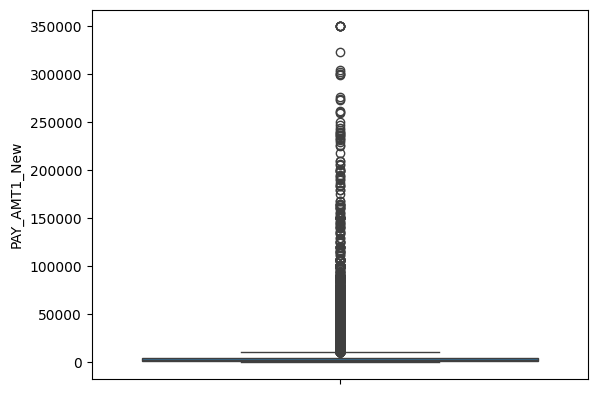

In [ ]:
#BOXPLOT
sns.boxplot(credit_risk_data['PAY_AMT1_New'])

In [ ]:
for i in range(2, 7):
    col_name = f'PAY_AMT{i}'
    new_col_name = f'{col_name}_New'
    credit_risk_data[new_col_name] = credit_risk_data[col_name]
    credit_risk_data.loc[credit_risk_data[col_name] < 0, new_col_name] = 0
    credit_risk_data.loc[credit_risk_data[col_name] > 350000, new_col_name] = 350000
    print(f"Description for {new_col_name}:")
    print(credit_risk_data[new_col_name].describe())
    print("\n")

Description for PAY_AMT2_New:
count     30000.000000
mean       5779.659000
std       17498.857944
min           0.000000
25%         833.000000
50%        2009.000000
75%        5000.000000
max      350000.000000
Name: PAY_AMT2_New, dtype: float64


Description for PAY_AMT3_New:
count     30000.000000
mean       5176.976167
std       15987.430827
min           0.000000
25%         390.000000
50%        1800.000000
75%        4505.000000
max      350000.000000
Name: PAY_AMT3_New, dtype: float64


Description for PAY_AMT4_New:
count     30000.000000
mean       4801.774433
std       14970.192320
min           0.000000
25%         296.000000
50%        1500.000000
75%        4013.250000
max      350000.000000
Name: PAY_AMT4_New, dtype: float64


Description for PAY_AMT5_New:
count     30000.000000
mean       4792.325733
std       15103.796781
min           0.000000
25%         252.500000
50%        1500.000000
75%        4031.500000
max      350000.000000
Name: PAY_AMT5_New, dtype: float6

In [ ]:
new_pay_vars=['PAY_AMT1_New','PAY_AMT2_New','PAY_AMT3_New','PAY_AMT4_New','PAY_AMT5_New','PAY_AMT6_New']
credit_risk_data[new_pay_vars].describe()

,PAY_AMT1_New,PAY_AMT2_New,PAY_AMT3_New,PAY_AMT4_New,PAY_AMT5_New,PAY_AMT6_New
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,5631.279567,5779.659000,5176.976167,4801.774433,4792.325733,5194.666333
std,15529.925010,17498.857944,15987.430827,14970.192320,15103.796781,17290.502865
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1000.000000,833.000000,390.000000,296.000000,252.500000,117.750000
50%,2100.000000,2009.000000,1800.000000,1500.000000,1500.000000,1500.000000
75%,5006.000000,5000.000000,4505.000000,4013.250000,4031.500000,4000.000000
max,350000.000000,350000.000000,350000.000000,350000.000000,350000.000000,350000.000000


# Model Building
Select the right model, Include Feature Engineering, Perform Model Validation, Multiple models and performance comparison


# Model Validation
Confusion matrix, Sensitivity, Specificity, F1 Score, Recall, Precision etc.

# Model  Deployment
## Optional step